# EvoCA — test notebook

Tests the C core (ctypes), verifies exact GoL, and launches the SDL2 interactive display.

Run cells in order.  **Build first**, then proceed.

## 1  Build

In [1]:
import subprocess, sys, os
root = os.path.abspath('')
# macOS: gcc -dynamiclib; Linux: gcc -shared
import platform
flag = '-dynamiclib' if platform.system() == 'Darwin' else '-shared'
ext  = 'dylib'      if platform.system() == 'Darwin' else 'so'
cmd  = ['gcc', '-O2', '-Wall', '-fPIC', flag,
        '-o', f'C/libevoca.{ext}', 'C/evoca.c']
r = subprocess.run(cmd, cwd=root, capture_output=True, text=True)
print(r.stdout or '(no stdout)')
if r.returncode != 0:
    print('STDERR:', r.stderr, file=sys.stderr)
    raise RuntimeError('Build failed')
print('Build OK')

(no stdout)
Build OK


## 2  Imports

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(''))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import time

from python.evoca_py import EvoCA, make_gol_lut, LUT_BYTES, lut_bit_index, unpack_lut
from python.display  import run as sdl_run
from python.controls import run_with_controls

/Users/n/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sdl2/dll.py:273: DLLWarning: OSError("dlopen(/usr/local/lib/libSDL2_ttf.dylib, 0x0006): tried: '/usr/local/lib/libSDL2_ttf.dylib' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64e.v1' or 'arm64' or 'arm64')), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/lib/libSDL2_ttf.dylib' (no such file), '/usr/local/lib/libSDL2_ttf.dylib' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64e.v1' or 'arm64' or 'arm64')), '/usr/local/lib/libSDL2_ttf-2.0.0.dylib' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64e.v1' or 'arm64' or 'arm64')), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/lib/libSDL2_ttf-2.0.0.dylib' (no such file), '/usr/local/lib/libSDL2_ttf-2.0.0.dylib' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64e.v1' or 'arm64' or 'arm64'))")
  warnings.warn(repr(exc), DLLWa

## 3  GoL LUT — correctness check

The LUT is indexed by **(v_x, n1, n2, n3)** where n1..n3 are per-ring
active-cell counts.  GoL depends only on `(v_x, n1+n2)`; n3 is ignored.
This is exact — no approximation.

LUT size: 2×5×5×5 = **250 bits** = **32 bytes/cell** (bit-packed).  
Memory: N=256 → ~3.4 MB; N=512 → ~13.6 MB.

In [3]:
gol_lut = make_gol_lut()
bits    = unpack_lut(gol_lut)
print(f'LUT size: {LUT_BYTES} bytes')

all_ok = True
for v_x in (0, 1):
    for moore in range(9):
        n1 = min(moore, 4); n2 = moore - n1
        if n2 > 4: continue
        got  = bits[lut_bit_index(v_x, n1, n2, 0)]
        want = (1 if moore == 3 else 0) if v_x == 0 else (1 if moore in (2,3) else 0)
        ok   = got == want
        all_ok &= ok
        print(f'  v={v_x} Moore={moore:2d}  LUT={got}  expected={want}  {"OK" if ok else "FAIL"}')

# n3 ignored — same result regardless of n3 value
assert bits[lut_bit_index(1, 2, 0, 3)] == 1
assert bits[lut_bit_index(0, 2, 1, 4)] == 1
print('\nn3-ignore checks OK')
print('\nAll GoL LUT entries correct:', all_ok)

LUT size: 32 bytes
  v=0 Moore= 0  LUT=0  expected=0  OK
  v=0 Moore= 1  LUT=0  expected=0  OK
  v=0 Moore= 2  LUT=0  expected=0  OK
  v=0 Moore= 3  LUT=1  expected=1  OK
  v=0 Moore= 4  LUT=0  expected=0  OK
  v=0 Moore= 5  LUT=0  expected=0  OK
  v=0 Moore= 6  LUT=0  expected=0  OK
  v=0 Moore= 7  LUT=0  expected=0  OK
  v=0 Moore= 8  LUT=0  expected=0  OK
  v=1 Moore= 0  LUT=0  expected=0  OK
  v=1 Moore= 1  LUT=0  expected=0  OK
  v=1 Moore= 2  LUT=1  expected=1  OK
  v=1 Moore= 3  LUT=1  expected=1  OK
  v=1 Moore= 4  LUT=0  expected=0  OK
  v=1 Moore= 5  LUT=0  expected=0  OK
  v=1 Moore= 6  LUT=0  expected=0  OK
  v=1 Moore= 7  LUT=0  expected=0  OK
  v=1 Moore= 8  LUT=0  expected=0  OK

n3-ignore checks OK

All GoL LUT entries correct: True


## 4  Glider test — exact GoL

A standard GoL glider has period 4 and moves (1,1) diagonally per period.
With the correct LUT this must be exact — no approximation.

In [ ]:
N = 64
sim = EvoCA()
sim.init(N, food_inc=0.0, m_scale=0.0)  # food/repro disabled
sim.set_lut_all(gol_lut)
sim.set_egenome_all(0); sim.set_f_all(0.0); sim.set_F_all(0.0)

grid = np.zeros((N, N), dtype=np.uint8)
r0, c0 = 10, 10
for dr, dc in [(0,1),(1,2),(2,0),(2,1),(2,2)]:
    grid[r0+dr, c0+dc] = 1
sim.set_v(grid)

STEPS = 40
frames = [sim.get_v().copy()]
for _ in range(STEPS):
    sim.step()
    frames.append(sim.get_v().copy())

alive = [f.sum() for f in frames]
print('Alive count per step (should stay at 5):', alive[:12])
assert all(a == 5 for a in alive), f'Glider lost cells: {alive}'

# verify diagonal travel
pos0 = np.argwhere(frames[0]).mean(0)
pos4 = np.argwhere(frames[4]).mean(0)
shift = pos4 - pos0
print(f'4-step shift: {shift}  (expect [1, 1])')
assert abs(shift[0]-1) < 0.1 and abs(shift[1]-1) < 0.1
print('Glider test PASSED — exact GoL confirmed')

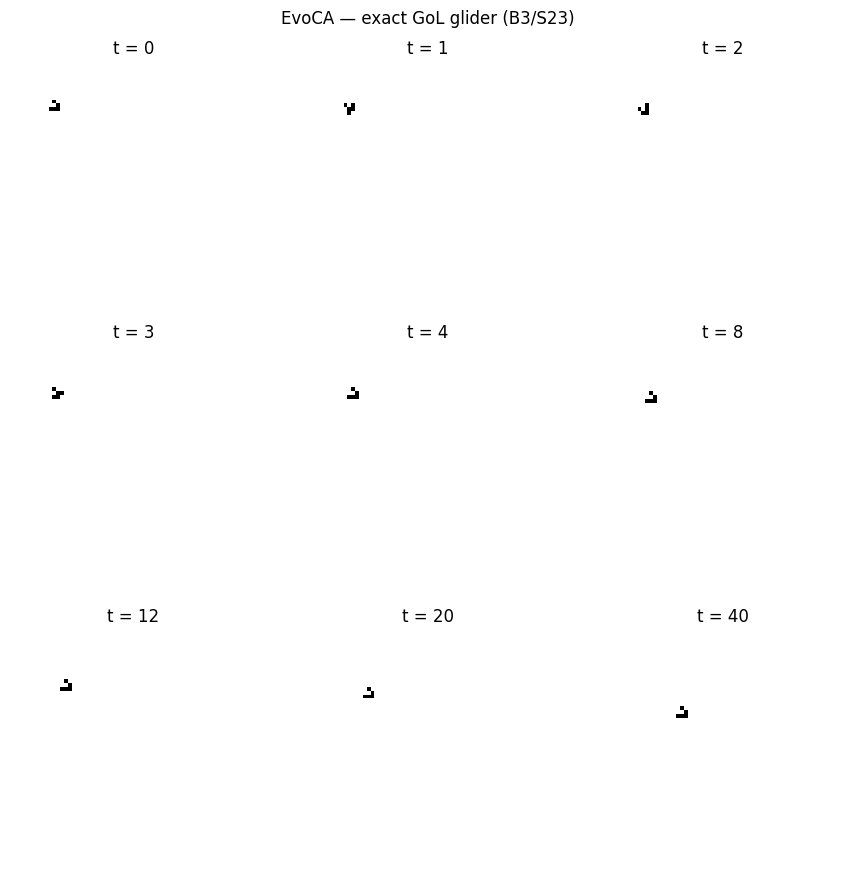

In [5]:
# Static snapshots
show_at = [0, 1, 2, 3, 4, 8, 12, 20, 40]
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, t in zip(axes.ravel(), show_at):
    ax.imshow(frames[t], cmap='binary', interpolation='nearest', vmin=0, vmax=1)
    ax.set_title(f't = {t}')
    ax.axis('off')
plt.suptitle('EvoCA — exact GoL glider (B3/S23)')
plt.tight_layout()
plt.show()

In [6]:
# Animation
fig2, ax2 = plt.subplots(figsize=(5,5))
im    = ax2.imshow(frames[0], cmap='binary', interpolation='nearest', vmin=0, vmax=1)
title = ax2.set_title('t = 0'); ax2.axis('off')
def _upd(t):
    im.set_data(frames[t]); title.set_text(f't = {t}'); return im, title
ani = animation.FuncAnimation(fig2, _upd, frames=len(frames), interval=120, blit=True)
plt.close(fig2)
HTML(ani.to_jshtml())

## 5  Performance benchmark

In [ ]:
sim.free()
rng = np.random.default_rng(42)
for N_test in (128, 256, 512):
    s = EvoCA(); s.init(N_test, 0, 0)
    s.set_lut_all(gol_lut)
    s.set_v(rng.integers(0, 2, (N_test, N_test), dtype=np.uint8))
    s.set_egenome_all(0); s.set_f_all(0); s.set_F_all(0)
    NSTEPS = 20
    t0 = time.perf_counter()
    for _ in range(NSTEPS): s.step()
    dt = time.perf_counter() - t0
    print(f'N={N_test:4d}:  {NSTEPS/dt:6.1f} fps  ({dt/NSTEPS*1000:.1f} ms/step)')
    s.free()

## 6  Interactive display — ipywidgets controls + SDL2 window

Controls appear in the cell output below; simulation renders in a separate SDL2 window.

- **Pause / Run** — toggle simulation
- **Step** — single step while paused
- **Quit** — close SDL2 window and return
- **Sliders** — adjust metaparams live; simulation auto-pauses during drag and resumes after
- **Color** dropdown — switch between state / env-food / priv-food views
- SDL2 keyboard: `SPACE` pause · `C` colour · `S` step · `Q`/`Esc` quit

In [ ]:
N = 512
rng2 = np.random.default_rng(0)

sim_sdl = EvoCA()
sim_sdl.init(N, food_inc=0.12, m_scale=0.4, mu_lut=0.001, tax=0.05)
sim_sdl.set_lut_all(gol_lut)
sim_sdl.set_egenome_all(0b000011)
sim_sdl.set_v(rng2.integers(0, 2, (N, N), dtype=np.uint8))
sim_sdl.set_f_all(0.1)
sim_sdl.set_F_all(0.5)

#run_with_controls(sim_sdl,paused=True)
run_with_controls(sim_sdl, paused=True, probes={'activity':True,'env_food': True, 'priv_food': True})
# Cell returns immediately.  Use widgets or Q/Esc in the SDL2 window to stop.

In [27]:
h = sim_sdl.get_repro_age_hist()

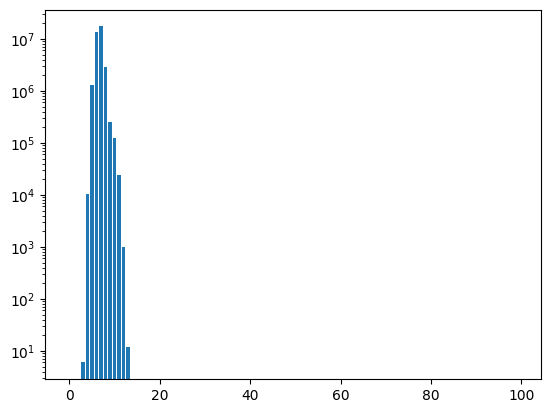

In [28]:
nn=100
plt.bar(range(nn),h[:nn]);
ax=plt.gca()
ax.set_yscale('log')

In [12]:
h[:60]

array([       0,        0,        0,        0,        0,        0,
              0,        0,        0,        0,        0,        0,
              0,        6,       56,      437,     3308,    21682,
         116215,   507114,  1724743,  4623166, 10280849, 25243811,
        6114602,  2359513,   806212,   223672,    57124,    12897,
           3141,      726,      293,       76,       64,        9,
             19,        7,       17,        3,        8,        0,
              3,       47,     4730,    65690,   149594,    30104,
              1,        0,        1,        0,        1,        0,
              0,        0,        1,        0,        0,        0],
      dtype=uint32)

In [32]:
foo=sim_sdl.get_lut(1)
len(foo)

32

In [33]:
foo

array([  0, 128,  15,   0, 248,   0,   4,  15,   4, 248,  64,  64,   1,
         1,  32,   8, 149, 255,   1, 232,  31, 144, 255,  65,  68,  31,
         2, 128,   4,   2,  12,   0], dtype=uint8)

In [22]:
food = sim_sdl.get_F()
len(food)

512

In [18]:
len(food)

0

In [16]:
import seaborn as sns

<Axes: ylabel='Density'>

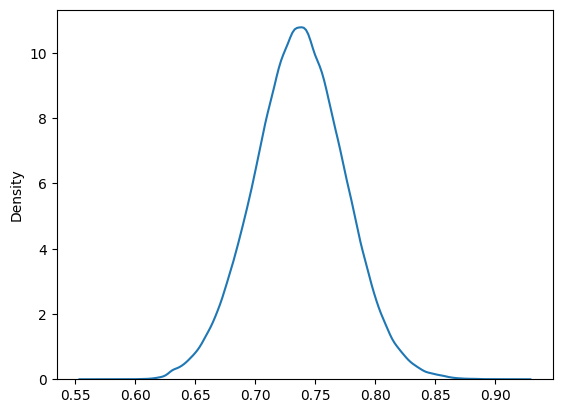

In [23]:
sns.kdeplot(data=food.flatten())

## 7  GoL-only SDL2 display  (food/eating disabled)

Use this to observe pure GoL dynamics with mutation=0.

In [ ]:
N = 512
rng3 = np.random.default_rng(7)

sim_gol = EvoCA()
sim_gol.init(N, food_inc=0.0, m_scale=0.0)
sim_gol.set_lut_all(gol_lut)
sim_gol.set_egenome_all(0)
sim_gol.set_v(rng3.integers(0, 2, (N, N), dtype=np.uint8))
sim_gol.set_f_all(0.0); sim_gol.set_F_all(0.0)

sdl_run(sim_gol)   # blocks until window closed
sim_gol.free()